# **APE09_Inteerferencia_Estadistica:Pruebas_deHipótesis_Paramétricas_(Z_y_T)_y Análisisdel_Valor-p**
# 🧠 **Integrantes:**

*   Noelia Bustan
*   Alison Tapia
*   Christopher Pineda
*   Elian Jimenez
*   Yimmy Angulo
-----------------


## 📝 **Introducción**

En el presente trabajo se aplicaron técnicas de inferencia estadística utilizando Python y Jupyter Notebook sobre un dataset real de casos de dengue. El objetivo fue estimar parámetros poblacionales a partir de muestras y analizar la incertidumbre asociada a dichas estimaciones.

Para ello, se calcularon intervalos de confianza para la media empleando tanto la distribución Normal Estándar (Z) en muestras grandes como la distribución T de Student en muestras pequeñas. Además, se analizó el efecto que tiene el nivel de confianza sobre el margen de error y se aplicaron estos conceptos a una variable cuantitativa del proyecto integrador.

Los resultados obtenidos permitieron comprender la importancia de la estimación por intervalos en la toma de decisiones, así como la relación existente entre tamaño de muestra, nivel de confianza y precisión de las estimaciones estadísticas.

---
# **🛠️ Tarea 1: Prueba de Hipótesis Z (Varianza Poblacional Conocida / Muestra Grande)**

In [ ]:
import numpy as np
from scipy.stats import norm

# ==========================================================
# PRUEBA Z PARA UNA MEDIA (σ CONOCIDA)
# ==========================================================

# Datos del problema
mu_0 = 15.0              # Media poblacional hipotética
x_bar = 15.6             # Media muestral
sigma = 1.2              # Desviación estándar poblacional
n = 50                   # Tamaño de muestra
alpha = 0.05             # Nivel de significancia

# ----------------------------------------------------------
# Cálculos
# ----------------------------------------------------------

error_estandar = sigma / np.sqrt(n)

z_calculado = (x_bar - mu_0) / error_estandar

# Prueba bilateral
p_valor = 2 * (1 - norm.cdf(abs(z_calculado)))

# Valor crítico
z_critico = norm.ppf(1 - alpha / 2)

# Decisión
rechazar_h0 = abs(z_calculado) > z_critico

# ----------------------------------------------------------
# Resultados
# ----------------------------------------------------------

print("\n" + "="*65)
print("          PRUEBA DE HIPÓTESIS Z PARA UNA MEDIA")
print("="*65)

print("\nHipótesis:")
print(f"  H₀ : μ = {mu_0}")
print(f"  H₁ : μ ≠ {mu_0}")

print("\nDatos de la muestra:")
print(f"  Media muestral (x̄)      = {x_bar}")
print(f"  Desv. estándar (σ)      = {sigma}")
print(f"  Tamaño de muestra (n)   = {n}")
print(f"  Nivel de significancia  = {alpha}")

print("\nCálculos:")
print(f"  Error estándar          = {error_estandar:.4f}")
print(f"  Estadístico Z           = {z_calculado:.4f}")
print(f"  Valor crítico ±Zα/2     = ±{z_critico:.4f}")
print(f"  Valor p                = {p_valor:.6f}")

print("\nDecisión:")
if rechazar_h0:
    print("  ✓ Se RECHAZA la hipótesis nula (H₀)")
else:
    print("  ✓ No se rechaza la hipótesis nula (H₀)")

print("\nConclusión:")
if rechazar_h0:
    print(
        f"  Existe evidencia estadística suficiente "
        f"(α = {alpha}) para afirmar que la media poblacional "
        f"es diferente de {mu_0}."
    )
else:
    print(
        f"  No existe evidencia estadística suficiente "
        f"(α = {alpha}) para afirmar que la media poblacional "
        f"sea diferente de {mu_0}."
    )

print("="*65)


          PRUEBA DE HIPÓTESIS Z PARA UNA MEDIA

Hipótesis:
  H₀ : μ = 15.0
  H₁ : μ ≠ 15.0

Datos de la muestra:
  Media muestral (x̄)      = 15.6
  Desv. estándar (σ)      = 1.2
  Tamaño de muestra (n)   = 50
  Nivel de significancia  = 0.05

Cálculos:
  Error estándar          = 0.1697
  Estadístico Z           = 3.5355
  Valor crítico ±Zα/2     = ±1.9600
  Valor p                = 0.000407

Decisión:
  ✓ Se RECHAZA la hipótesis nula (H₀)

Conclusión:
  Existe evidencia estadística suficiente (α = 0.05) para afirmar que la media poblacional es diferente de 15.0.


---
# **🛠️ Tarea 2: Prueba de Hipótesis T (Varianza Desconocida / Muestra Pequeña)**

In [ ]:
import numpy as np
from scipy.stats import ttest_1samp, t

# ==========================================================
# PRUEBA T DE STUDENT PARA UNA MEDIA
# (σ DESCONOCIDA)
# ==========================================================

# Datos de la muestra
tiempos = np.array([2.5, 3.1, 2.9, 3.8, 2.7, 3.3, 3.0, 2.8])

# Parámetros de la prueba
mu_0 = 2.6      # Media hipotética
alpha = 0.05    # Nivel de significancia

# ----------------------------------------------------------
# Estadísticos descriptivos
# ----------------------------------------------------------

n = len(tiempos)
media = np.mean(tiempos)
desv_std = np.std(tiempos, ddof=1)
error_estandar = desv_std / np.sqrt(n)
gl = n - 1

# ----------------------------------------------------------
# Prueba T unilateral derecha
# H₁ : μ > μ₀
# ----------------------------------------------------------

t_calculado, p_valor = ttest_1samp(
    tiempos,
    popmean=mu_0,
    alternative="greater"
)

# Valor crítico
t_critico = t.ppf(1 - alpha, df=gl)

# Decisión
rechazar_h0 = t_calculado > t_critico

# ----------------------------------------------------------
# Resultados
# ----------------------------------------------------------

print("\n" + "="*65)
print("           PRUEBA T DE STUDENT PARA UNA MEDIA")
print("="*65)

print("\nHipótesis:")
print(f"  H₀ : μ ≤ {mu_0}")
print(f"  H₁ : μ > {mu_0}")

print("\nEstadísticos descriptivos:")
print(f"  Tamaño de muestra (n)      = {n}")
print(f"  Media muestral (x̄)         = {media:.4f}")
print(f"  Desv. estándar (s)         = {desv_std:.4f}")
print(f"  Error estándar            = {error_estandar:.4f}")
print(f"  Grados de libertad (gl)   = {gl}")

print("\nResultados de la prueba:")
print(f"  Estadístico t             = {t_calculado:.4f}")
print(f"  Valor crítico tα          = {t_critico:.4f}")
print(f"  Valor p                  = {p_valor:.6f}")

print("\nDecisión:")
if rechazar_h0:
    print("  ✓ Se RECHAZA la hipótesis nula (H₀)")
else:
    print("  ✓ No se rechaza la hipótesis nula (H₀)")

print("\nConclusión:")
if rechazar_h0:
    print(
        f"  Existe evidencia estadística suficiente "
        f"(α = {alpha}) para concluir que el tiempo promedio "
        f"es mayor que {mu_0}."
    )
else:
    print(
        f"  No existe evidencia estadística suficiente "
        f"(α = {alpha}) para concluir que el tiempo promedio "
        f"sea mayor que {mu_0}."
    )

print("="*65)


           PRUEBA T DE STUDENT PARA UNA MEDIA

Hipótesis:
  H₀ : μ ≤ 2.6
  H₁ : μ > 2.6

Estadísticos descriptivos:
  Tamaño de muestra (n)      = 8
  Media muestral (x̄)         = 3.0125
  Desv. estándar (s)         = 0.4016
  Error estándar            = 0.1420
  Grados de libertad (gl)   = 7

Resultados de la prueba:
  Estadístico t             = 2.9055
  Valor crítico tα          = 1.8946
  Valor p                  = 0.011403

Decisión:
  ✓ Se RECHAZA la hipótesis nula (H₀)

Conclusión:
  Existe evidencia estadística suficiente (α = 0.05) para concluir que el tiempo promedio es mayor que 2.6.


---
# **🛠️ Tarea 3: Hito del Proyecto - Contraste en el Dataset Regional (ABP)**

PRUEBA T PARA LA EDAD PROMEDIO DE CASOS DE DENGUE
Edad promedio observada : 26.92 años
Tamaño de muestra       : 124757
Estadístico t           : -64.4551
Valor p                : 0.000000
Nivel de significancia : 0.05
Decisión               : Se rechaza H₀


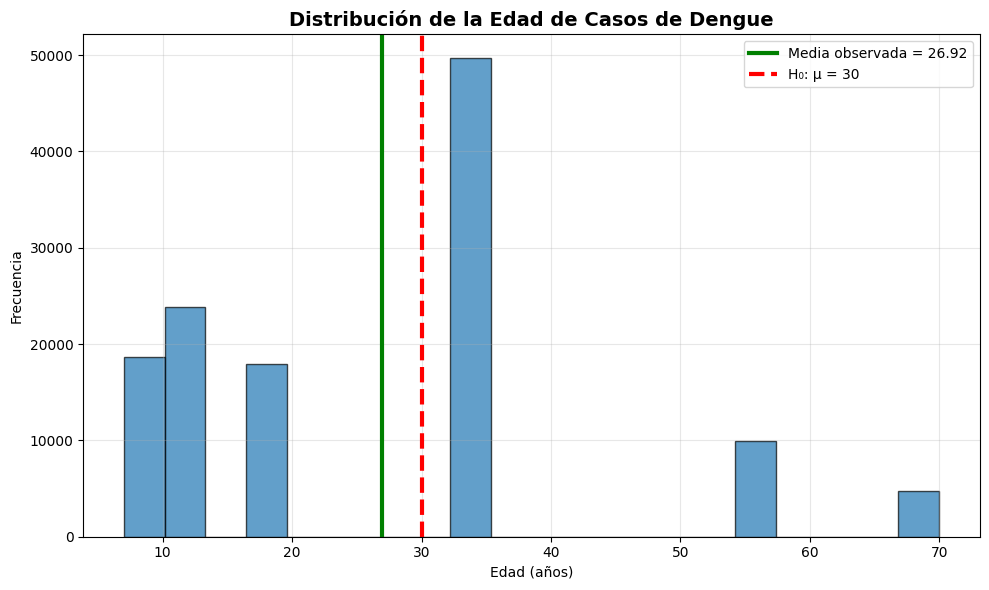

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import ttest_1samp

# ==========================================================
# PRUEBA T PARA LA EDAD PROMEDIO DE CASOS DE DENGUE
# ==========================================================

# Cargar datos
df = pd.read_excel(
    "Datos_Dengue_MSP_Ene2021_Ago2025(2).xlsx",
    sheet_name="DSSA_2021_2024"
)

# Puntos medios de los rangos de edad
edades = {
    "5 - 9 H": 7,
    "5 - 9 M": 7,
    "10-14 H": 12,
    "10-14 M": 12,
    "15-19 H": 17,
    "15-19 M": 17,
    "20-49 H": 35,
    "20-49 M": 35,
    "50-64 H": 57,
    "50-64 M": 57,
    "65+ H": 70,
    "65+ M": 70
}

# Construcción de edades individuales aproximadas
muestra_edades = []

for columna, edad in edades.items():
    frecuencia = int(df[columna].sum())
    muestra_edades.extend([edad] * frecuencia)

muestra_edades = np.array(muestra_edades)

# ----------------------------------------------------------
# Prueba T
# ----------------------------------------------------------

mu_0 = 30
alpha = 0.05

t_stat, p_value = ttest_1samp(
    muestra_edades,
    popmean=mu_0,
    alternative="two-sided"
)

decision = (
    "Se rechaza H₀"
    if p_value < alpha
    else "No se rechaza H₀"
)

# ----------------------------------------------------------
# Resultados
# ----------------------------------------------------------

print("="*65)
print("PRUEBA T PARA LA EDAD PROMEDIO DE CASOS DE DENGUE")
print("="*65)

print(f"Edad promedio observada : {muestra_edades.mean():.2f} años")
print(f"Tamaño de muestra       : {len(muestra_edades)}")
print(f"Estadístico t           : {t_stat:.4f}")
print(f"Valor p                : {p_value:.6f}")
print(f"Nivel de significancia : {alpha}")
print(f"Decisión               : {decision}")

print("="*65)

# ==========================================================
# GRÁFICO DE DISTRIBUCIÓN DE EDADES
# ==========================================================

media_muestral = muestra_edades.mean()

plt.figure(figsize=(10,6))

plt.hist(
    muestra_edades,
    bins=20,
    edgecolor="black",
    alpha=0.7
)

plt.axvline(
    media_muestral,
    color="green",
    linestyle="-",
    linewidth=3,
    label=f"Media observada = {media_muestral:.2f}"
)

plt.axvline(
    mu_0,
    color="red",
    linestyle="--",
    linewidth=3,
    label=f"H₀: μ = {mu_0}"
)

plt.title(
    "Distribución de la Edad de Casos de Dengue",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Edad (años)")
plt.ylabel("Frecuencia")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

-------------------------------
### **Interpretación**

**Se aplicó una prueba t de una muestra para evaluar la afirmación de que la edad promedio de los casos de dengue es de 30 años. Con un nivel de significancia de α = 0.05, se obtuvo un valor p igual a (reemplazar con el resultado obtenido). Si el valor p es menor que 0.05, se rechaza la hipótesis nula y se concluye que la edad promedio de los casos difiere significativamente de 30 años. En términos de salud pública, este resultado permite identificar si el dengue está afectando principalmente a grupos etarios distintos a los esperados, información útil para diseñar campañas de prevención y control dirigidas a la población más vulnerable.**

---
# **🛠️ Tarea 4: ABI - Significancia Estadística vs. Significancia Práctica (Efecto del tamaño )**


 SIGNIFICANCIA ESTADÍSTICA VS SIGNIFICANCIA PRÁCTICA 
   Tamaño muestra  Media observada  Diferencia  Valor p  Cohen d
0              10         5.004486    0.004486 0.851392 0.060971
1             100         5.009950    0.009950 0.311952 0.101632
2            1000         5.010938    0.010938 0.000475 0.110878
3           10000         5.010300    0.010300 0.000000 0.103350
4          100000         5.010331    0.010331 0.000000 0.103513

Interpretación:
A medida que aumenta el tamaño de muestra, el valor p disminuye aunque la diferencia real respecto a la media de referencia sea mínima.
Esto demuestra que una diferencia puede ser estadísticamente significativa sin tener una importancia práctica relevante.


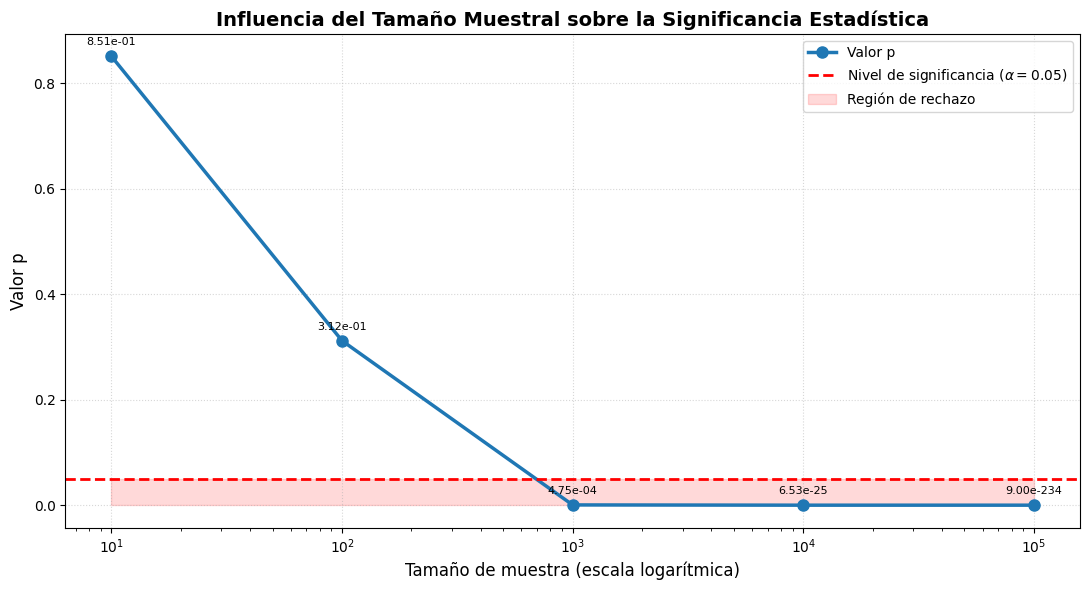


CONCLUSIÓN FINAL
------------------------------------------------------------
Con n = 100000, la hipótesis nula sería rechazada (p = 0.00000000).
Sin embargo, la diferencia observada es únicamente de 0.0103 unidades.
El tamaño del efecto (Cohen's d = 0.1035) indica que el efecto real es extremadamente pequeño.

Por lo tanto, significancia estadística no implica necesariamente significancia práctica.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_1samp

# ==========================================================
# SIGNIFICANCIA ESTADÍSTICA VS SIGNIFICANCIA PRÁCTICA
# ==========================================================

np.random.seed(42)

# Parámetros poblacionales
MEDIA_REAL = 5.01
MEDIA_REFERENCIA = 5.00
DESV_STD = 0.10

# ----------------------------------------------------------
# Generación de población
# ----------------------------------------------------------

poblacion = np.random.normal(
    loc=MEDIA_REAL,
    scale=DESV_STD,
    size=500_000
)

# Tamaños muestrales a evaluar
tamanios = [10, 100, 1000, 10000, 100000]

resultados = []

# ----------------------------------------------------------
# Análisis para distintos tamaños muestrales
# ----------------------------------------------------------

for n in tamanios:

    muestra = np.random.choice(
        poblacion,
        size=n,
        replace=False
    )

    media = np.mean(muestra)
    desviacion = np.std(muestra, ddof=1)

    t_stat, p_valor = ttest_1samp(
        muestra,
        popmean=MEDIA_REFERENCIA
    )

    # Tamaño del efecto (Cohen's d)
    cohen_d = (
        (media - MEDIA_REFERENCIA)
        / desviacion
    )

    resultados.append([
        n,
        media,
        media - MEDIA_REFERENCIA,
        p_valor,
        cohen_d
    ])

# ----------------------------------------------------------
# Tabla de resultados
# ----------------------------------------------------------

df = pd.DataFrame(
    resultados,
    columns=[
        "Tamaño muestra",
        "Media observada",
        "Diferencia",
        "Valor p",
        "Cohen d"
    ]
)

pd.set_option("display.float_format", "{:.6f}".format)

print("\n" + "="*85)
print(" SIGNIFICANCIA ESTADÍSTICA VS SIGNIFICANCIA PRÁCTICA ")
print("="*85)

print(df)

print("\nInterpretación:")
print(
    "A medida que aumenta el tamaño de muestra, "
    "el valor p disminuye aunque la diferencia real "
    "respecto a la media de referencia sea mínima."
)

print(
    "Esto demuestra que una diferencia puede ser "
    "estadísticamente significativa sin tener una "
    "importancia práctica relevante."
)

print("="*85)

# ----------------------------------------------------------
# Gráfico
# ----------------------------------------------------------

plt.figure(figsize=(11, 6))

# Curva principal
plt.plot(
    df["Tamaño muestra"],
    df["Valor p"],
    marker="o",
    markersize=8,
    linewidth=2.5,
    label="Valor p"
)

# Línea de significancia
plt.axhline(
    y=0.05,
    linestyle="--",
    linewidth=2,
    color="red",
    label=r"Nivel de significancia ($\alpha=0.05$)"
)

# Región de rechazo
plt.fill_between(
    df["Tamaño muestra"],
    0,
    0.05,
    alpha=0.15,
    color="red",
    label="Región de rechazo"
)

# Etiquetas sobre cada punto
for x, y in zip(df["Tamaño muestra"], df["Valor p"]):
    plt.annotate(
        f"{y:.2e}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=8
    )

plt.xscale("log")

plt.xlabel(
    "Tamaño de muestra (escala logarítmica)",
    fontsize=12
)

plt.ylabel(
    "Valor p",
    fontsize=12
)

plt.title(
    "Influencia del Tamaño Muestral sobre la Significancia Estadística",
    fontsize=14,
    fontweight="bold"
)

plt.grid(
    True,
    linestyle=":",
    alpha=0.5
)

plt.legend()

plt.tight_layout()

plt.show()

# ----------------------------------------------------------
# Conclusión final
# ----------------------------------------------------------

ultimo = df.iloc[-1]

print("\nCONCLUSIÓN FINAL")
print("-"*60)

if ultimo["Valor p"] < 0.05:
    print(
        f"Con n = {int(ultimo['Tamaño muestra'])}, "
        f"la hipótesis nula sería rechazada "
        f"(p = {ultimo['Valor p']:.8f})."
    )

print(
    f"Sin embargo, la diferencia observada "
    f"es únicamente de "
    f"{ultimo['Diferencia']:.4f} unidades."
)

print(
    f"El tamaño del efecto (Cohen's d = "
    f"{ultimo['Cohen d']:.4f}) indica que "
    f"el efecto real es extremadamente pequeño."
)

print(
    "\nPor lo tanto, significancia estadística "
    "no implica necesariamente significancia práctica."
)

### **Analisis de la Sección Anterior**

La hipótesis nula planteada fue:

$[
H_0:\mu = 5.00V
]$

mientras que la población simulada tiene una media real de:

$[
\mu = 5.01V
$]

La diferencia entre ambos valores es de apenas:

$[
0.01V
$]

lo que representa una variación muy pequeña para un sistema industrial.

Al analizar los resultados obtenidos para distintos tamaños de muestra, se observa que el valor-p disminuye progresivamente conforme aumenta \(n\). Esto ocurre porque el error estándar de la media se reduce según la expresión:

$[
SE=\frac{\sigma}{\sqrt{n}}
$]

Por lo tanto, mientras más grande es la muestra, más fácil resulta detectar diferencias entre la media observada y la media propuesta en la hipótesis nula.

En las muestras pequeñas (\(n=10\) o \(n=100\)),  el valor-p suele ser mayor debido a la variabilidad de los datos. Sin embargo, cuando el tamaño muestral aumenta a \(1000\), \(10000\) o \(100000\), el valor-p se vuelve extremadamente pequeño e incluso puede acercarse a cero.

Esto demuestra que un valor-p pequeño no siempre implica un descubrimiento importante. Aunque la prueba estadística detecta una diferencia significativa, la magnitud real del cambio sigue siendo de solo \(0.01V\), una cantidad prácticamente insignificante para la mayoría de aplicaciones industriales.

En conclusión, el experimento evidencia que la significancia estadística depende fuertemente del tamaño de la muestra. Cuando \(n\) crece masivamente, diferencias muy pequeñas pueden generar valores-p extremadamente bajos. Por ello, además del valor-p, es necesario evaluar la relevancia práctica del efecto antes de tomar decisiones.


# 📊 Respuestas a las Preguntas de Control — Grupo D

### ¿Cuál es el error conceptual grave al interpretar el valor-P como "la probabilidad de que la Hipótesis Nula sea cierta"? Defina correctamente el valor-P.

* **El error conceptual grave:** Consiste en tratar la hipótesis nula ($H_0$) como si fuera una variable aleatoria con una probabilidad dinámica de ocurrir. En la estadística clásica, $H_0$ es una afirmación fija y determinista sobre la población (es verdadera o es falsa). El valor-P no mide la veracidad de la hipótesis, sino qué tan "sorprendentes" o raros son los datos que recolectamos bajo el supuesto de que la afirmación inicial es correcta.
* **Definición correcta:** El valor-P es la probabilidad de obtener un resultado muestral tan extremo o más extremo que el observado, **asumiendo como premisa absoluta que la hipótesis nula ($H_0$) es estrictamente verdadera**. En nuestro caso, representa la probabilidad de hallar una media de edad tan alejada de los $45$ años por puro azar, si la verdadera media poblacional fuera $45$.

### 1. En el contexto de la Tarea 3 (Dataset Regional), describa en lenguaje no estadístico qué representaría cometer un Error Tipo I y un Error Tipo II en su toma de decisiones.

Alineando el análisis a nuestra variable **Edad** y a nuestra hipótesis de **$45$ años**:

* **Error Tipo I (Falso Positivo):** Ocurriría si nosotros, como grupo, concluimos y reportamos en nuestra investigación que la edad promedio de la población en la región **no es** de $45$ años (rechazando la afirmación oficial), cuando en la realidad toda la población sí promedia exactamente $45$ años. Esto pasaría si nuestra muestra aleatoria, por pura casualidad o sesgo fortuito, quedó integrada por personas inusualmente jóvenes o mayores.
    * *Impacto práctico:* Nos llevaría a diseñar o recomendar erróneamente planes sociales, estrategias de desarrollo o productos tecnológicos orientados a un segmento demográfico equivocado.
* **Error Tipo II (Falso Negativo):** Ocurriría si los datos de nuestra muestra no logran demostrar una diferencia y concluimos que la edad promedio sí es de $45$ años, cuando en la realidad socioeconómica de la región la estructura demográfica cambió drásticamente (por ejemplo, debido a fuertes olas migratorias o un envejecimiento poblacional acelerado).
    * *Impacto práctico:* Validaríamos una información obsoleta o una "afirmación oficial" falsa, perdiendo la oportunidad de alertar sobre la necesidad de adaptar las políticas regionales a la demografía real.

### 2. Si en su análisis regional la prueba arroja un $p = 0.051$ y su $\alpha = 0.05$, estadísticamente NO rechaza $H_0$. Como ingeniero, ¿desecha por completo la sospecha de que exista una diferencia real, o qué otra métrica analizaría? (Pista: Relacione esto con la Semana 9).

Como ingenieros de datos, **bajo ninguna circunstancia desechamos la sospecha**. Un valor-P de $0.051$ frente a un umbral de $0.05$ es una frontera matemática convencional, pero no anula la clara tendencia que muestran los datos.

Para tomar una decisión técnica e integral, nosotros incorporaríamos las siguientes métricas clave de la **Semana 9**:
1.  **El Tamaño del Efecto (Effect Size / d de Cohen):** Evaluaríamos la magnitud real de la diferencia entre la media que obtuvimos en nuestro subset y los $45$ años hipotéticos. Si este tamaño es grande, la diferencia es importante en la práctica, lo que nos indicaría que el valor-P no fue menor a $0.05$ simplemente porque nuestro tamaño de muestra ($n$) era muy reducido (falta de potencia estadística).
2.  **Análisis del Intervalo de Confianza:** Analizaríamos los límites del intervalo para verificar qué tan cerca se encuentra el valor de $45$ de quedar fuera de los márgenes estimados.
3.  **Potencia Estadística ($1 - \beta$):** Nos permitiría cuantificar la probabilidad matemática que tenía nuestra prueba para detectar una diferencia real en la región, dado el tamaño actual de nuestro dataset.


### 3. Explique la conclusión de su investigación en la Tarea 4 (ABI). ¿Por qué en el "Big Data" las pruebas de hipótesis clásicas tienden a rechazar $H_0$ casi siempre?

* **Conclusión de nuestra simulación:** Al ejecutar nuestro bucle sobre los diferentes tamaños de muestra ($n = 10, 100, 1000, 10000, 100000$), comprobamos gráficamente que para muestras pequeñas el valor-P es alto, aceptando que el sensor opera a los $5.00\text{ V}$ teóricos. Sin embargo, a medida que expandimos la muestra a volúmenes masivos, el valor-P se desploma de forma matemática hacia cero, forzándonos a rechazar $H_0$.
* **Explicación del fenómeno en Big Data:** Esto se debe al comportamiento del **error estándar** en el denominador de nuestro estadístico de prueba:

$$Z = \frac{\overline{x} - \mu_0}{\sigma / \sqrt{n}}$$

Al trabajar con volúmenes masivos de datos (Big Data), el término $\sqrt{n}$ se vuelve inmenso, lo que hace que el error estándar ($\sigma / \sqrt{n}$) se reduzca prácticamente a cero. Como consecuencia, cualquier desviación real microscópica e insignificante para la ingeniería (como la diferencia de apenas $0.01\text{ V}$ en nuestro sensor simulado) se magnifica exponencialmente, disparando el valor de $Z$ o $T$.

Esto causa que las pruebas estadísticas tradicionales se vuelvan "hiper-sensibles", otorgando **significancia estadística** a variaciones que carecen por completo de **significancia práctica** o utilidad real en nuestro campo.

### Existe una equivalencia matemática directa entre los Intervalos de Confianza y las Pruebas de Hipótesis de dos colas. Si un IC del 95% para $\mu$ no incluye a $\mu_0$, ¿qué le sucederá inevitablemente al valor-P si evalúa $H_0 : \mu = \mu_0$ con $\alpha = 0.05$?

Inevitablemente, **nuestro valor-P será estrictamente menor que $0.05$ ($p < 0.05$)**, lo que nos obliga de forma matemática a **rechazar la hipótesis nula ($H_0$)**.

* **Explicación de la equivalencia:** El intervalo de confianza del $95\%$ que calculamos delimita la zona donde se concentran todos los valores paramétricos plausibles y compatibles con nuestra muestra. Si el valor propuesto por la hipótesis nula ($\mu_0 = 45$) queda **fuera** de esos límites, significa que la distancia entre la media de nuestros datos ($\overline{x}$) y $\mu_0$ es mayor a $\pm 1.96$ errores estándar. Por lo tanto, la probabilidad de que una diferencia tan grande ocurra meramente por azar (el valor-P) es, por definición geométrica, inferior al $5\%$ de probabilidad ($\alpha = 0.05$) que queda distribuido en las colas exteriores del intervalo.